In [116]:
import seaborn as sns

df = sns.load_dataset('iris')
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [117]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [118]:
from sklearn.preprocessing import LabelEncoder

In [119]:
encoder = LabelEncoder()

In [120]:
df['species'] = encoder.fit_transform(df['species'])

In [121]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [122]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [123]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

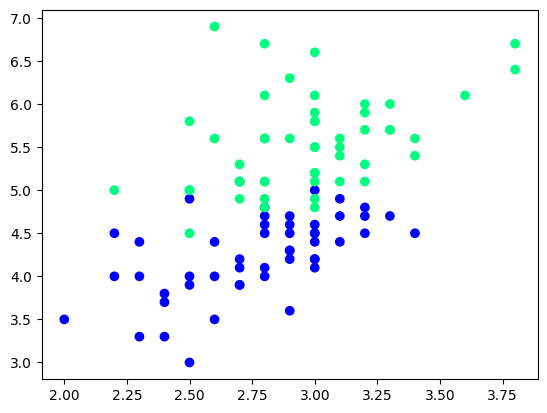

In [125]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [126]:
df_train = df.iloc[:60,:].sample(10)
df_train

#taking only 10 rows

,sepal_width,petal_length,species
82,2.7,3.9,1
104,3.0,5.8,2
70,3.2,4.8,1
101,2.7,5.1,2
71,2.8,4.0,1
62,2.2,4.0,1
99,2.8,4.1,1
90,2.6,4.4,1
79,2.6,3.5,1
68,2.2,4.5,1


In [127]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [128]:
df_train

,sepal_width,petal_length,species
111,2.7,5.3,2
104,3.0,5.8,2
145,3.0,5.2,2
54,2.8,4.6,1
75,3.0,4.4,1
51,3.2,4.5,1
89,2.5,4.0,1
103,2.9,5.6,2
108,2.5,5.8,2
130,2.8,6.1,2


In [129]:
df_val

,sepal_width,petal_length,species
149,3.0,5.1,2
117,3.8,6.7,2
102,3.0,5.9,2
62,2.2,4.0,1
135,3.0,6.1,2


In [130]:
df_test

,sepal_width,petal_length,species
74,2.9,4.3,1
83,2.7,5.1,1
50,3.2,4.7,1
147,3.0,5.2,2
69,2.5,3.9,1


In [131]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [132]:
y_test

array([2, 2, 2, 1, 2])

# Case 1 - Bagging

In [133]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
54,2.8,4.6,1
89,2.5,4.0,1
75,3.0,4.4,1
103,2.9,5.6,2
103,2.9,5.6,2
51,3.2,4.5,1
111,2.7,5.3,2
130,2.8,6.1,2


In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [135]:
dt_bag1 = DecisionTreeClassifier()

In [136]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

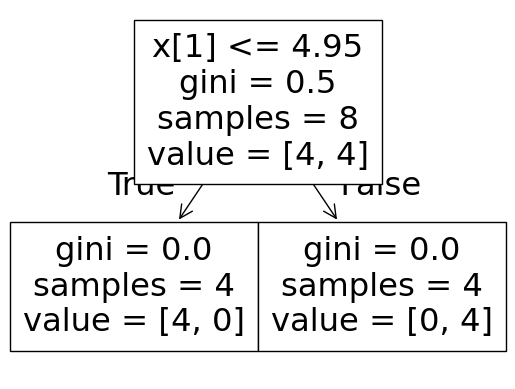

1.0


F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


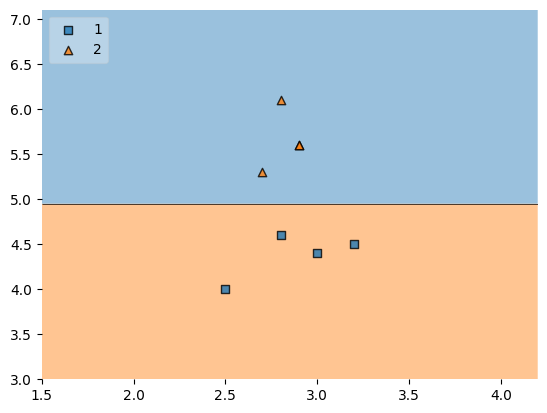

In [137]:
evaluate(dt_bag1,X,y)

In [138]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
104,3.0,5.8,2
108,2.5,5.8,2
51,3.2,4.5,1
51,3.2,4.5,1
103,2.9,5.6,2
75,3.0,4.4,1
75,3.0,4.4,1
89,2.5,4.0,1


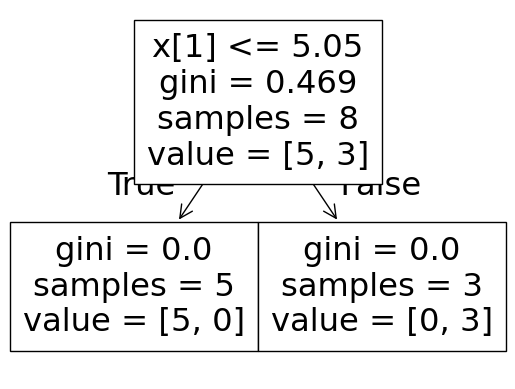

1.0


F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


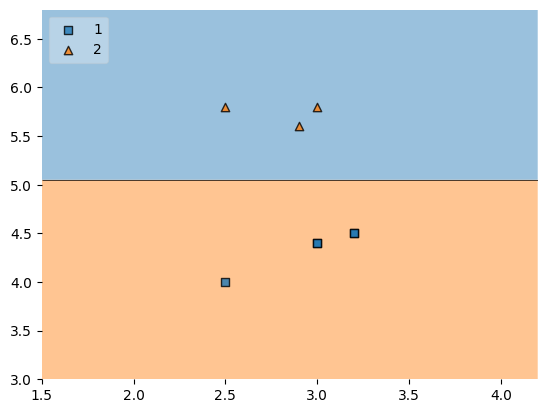

In [139]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [140]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
130,2.8,6.1,2
89,2.5,4.0,1
75,3.0,4.4,1
51,3.2,4.5,1
111,2.7,5.3,2
104,3.0,5.8,2
108,2.5,5.8,2
54,2.8,4.6,1


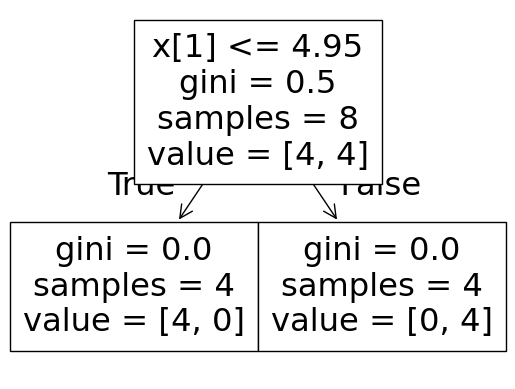

1.0


F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


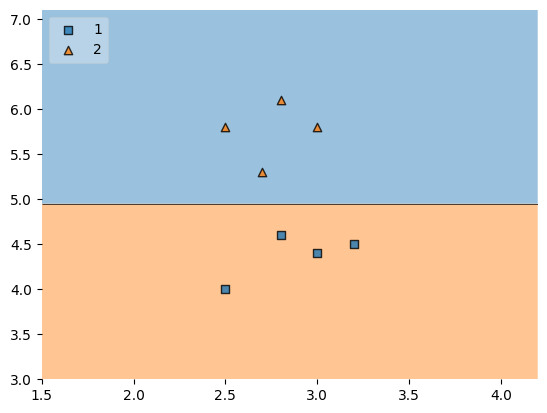

In [141]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [142]:
df_test

,sepal_width,petal_length,species
74,2.9,4.3,1
83,2.7,5.1,1
50,3.2,4.7,1
147,3.0,5.2,2
69,2.5,3.9,1


In [143]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [1]
Predictor 3 [2]


F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
F:\ANACONDA\envs\ds\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [144]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
111,2.7,5.3,2
104,3.0,5.8,2
145,3.0,5.2,2
54,2.8,4.6,1
75,3.0,4.4,1
51,3.2,4.5,1
89,2.5,4.0,1
103,2.9,5.6,2
108,2.5,5.8,2
130,2.8,6.1,2


In [145]:
df_train.sample(8)

,sepal_width,petal_length,species
111,2.7,5.3,2
54,2.8,4.6,1
75,3.0,4.4,1
103,2.9,5.6,2
108,2.5,5.8,2
130,2.8,6.1,2
89,2.5,4.0,1
51,3.2,4.5,1


# Random Subspaces

In [146]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/iris/Iris.csv'

In [ ]:
df1

In [ ]:
df1.sample(2,replace=True,axis=1)

# Random Patches

In [ ]:
df1

In [ ]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)